# Checking RLE mask be loaded to model

In [1]:
import sys, os, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from PIL import Image
from pathlib import Path
import pycocotools.mask as mask_utils

ROOT = Path.cwd().parent
DATA = os.path.join(ROOT, "data/nvidia_warehouse_dataset")
sys.path.insert(0, ROOT)

In [2]:
# Load sample data
with open(os.path.join(DATA, "train_sample/train_sample.json")) as f:
    data = json.load(f)

# Pick first sample 
sample = data[0]
image_name = sample["image"]
category = sample["category"]
answer = sample["normalized_answer"]
question = sample["conversations"][0]["value"].replace("<image>\n", "")
answer_text = sample["conversations"][1]["value"]
rle_list = sample["rle"]
n_masks = len(rle_list)

print(f"Image:       {image_name}")
print(f"Category:    {category}")
print(f"Norm answer: {answer}")
print(f"Answer text: {answer_text}")
print(f"Masks:       {n_masks}")
print(f"Question:    {question}")

# Load RGB image
img = Image.open(os.path.join(DATA, "train_sample/images", image_name)).convert("RGB")
img_np = np.array(img)
H, W = img_np.shape[:2]

Image:       054690.png
Category:    mcq
Norm answer: 5
Answer text: The transporter [Region 1] is not transporting any boxes. The pallet [Region 5] is the closest to transporter [Region 1], so it is the most suitable choice for automated picking.
Masks:       9
Question:    Given the available transporters <mask> <mask> and pallets <mask> <mask> <mask> <mask> <mask> <mask> <mask>, which pallet is the best choice for automated pickup by an empty transporter?


In [3]:
# Decode all RLE masks
masks = []
for rle in rle_list:
    binary = mask_utils.decode(rle).astype(bool)  # [H, W]
    masks.append(binary)
# Color palette for masks
colors = plt.cm.tab10(np.linspace(0, 1, max(n_masks, 10)))

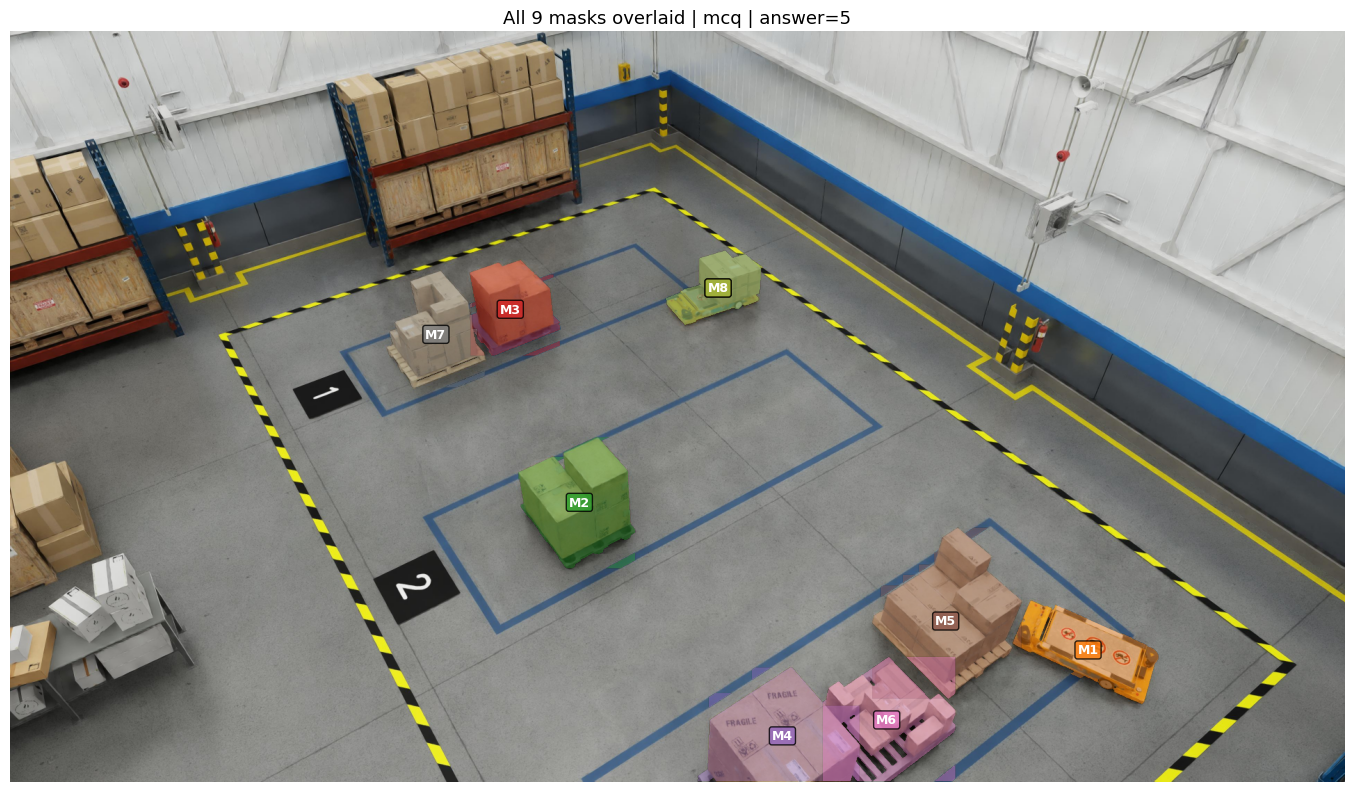

In [4]:
# ============================================================
# Plot 1: RGB + ALL masks overlaid
# ============================================================
fig, axes = plt.subplots(1, 1, figsize=(14, 8))
axes.imshow(img_np)
axes.set_title(f"All {n_masks} masks overlaid | {category} | answer={answer}", fontsize=13)
for i, mask in enumerate(masks):
    # Create colored overlay
    overlay = np.zeros((*mask.shape, 4), dtype=np.float32)
    overlay[mask, :3] = colors[i][:3]
    overlay[mask, 3] = 0.4  # alpha
    axes.imshow(overlay)

    # Mask centroid for label
    ys, xs = np.where(mask)
    if len(xs) > 0:
        cx, cy = xs.mean(), ys.mean()
        axes.text(cx, cy, f"M{i}", color="white", fontsize=9,
                  fontweight="bold", ha="center", va="center",
                  bbox=dict(boxstyle="round,pad=0.2", fc=colors[i][:3], alpha=0.8))
axes.axis("off")
plt.tight_layout()
plt.show()

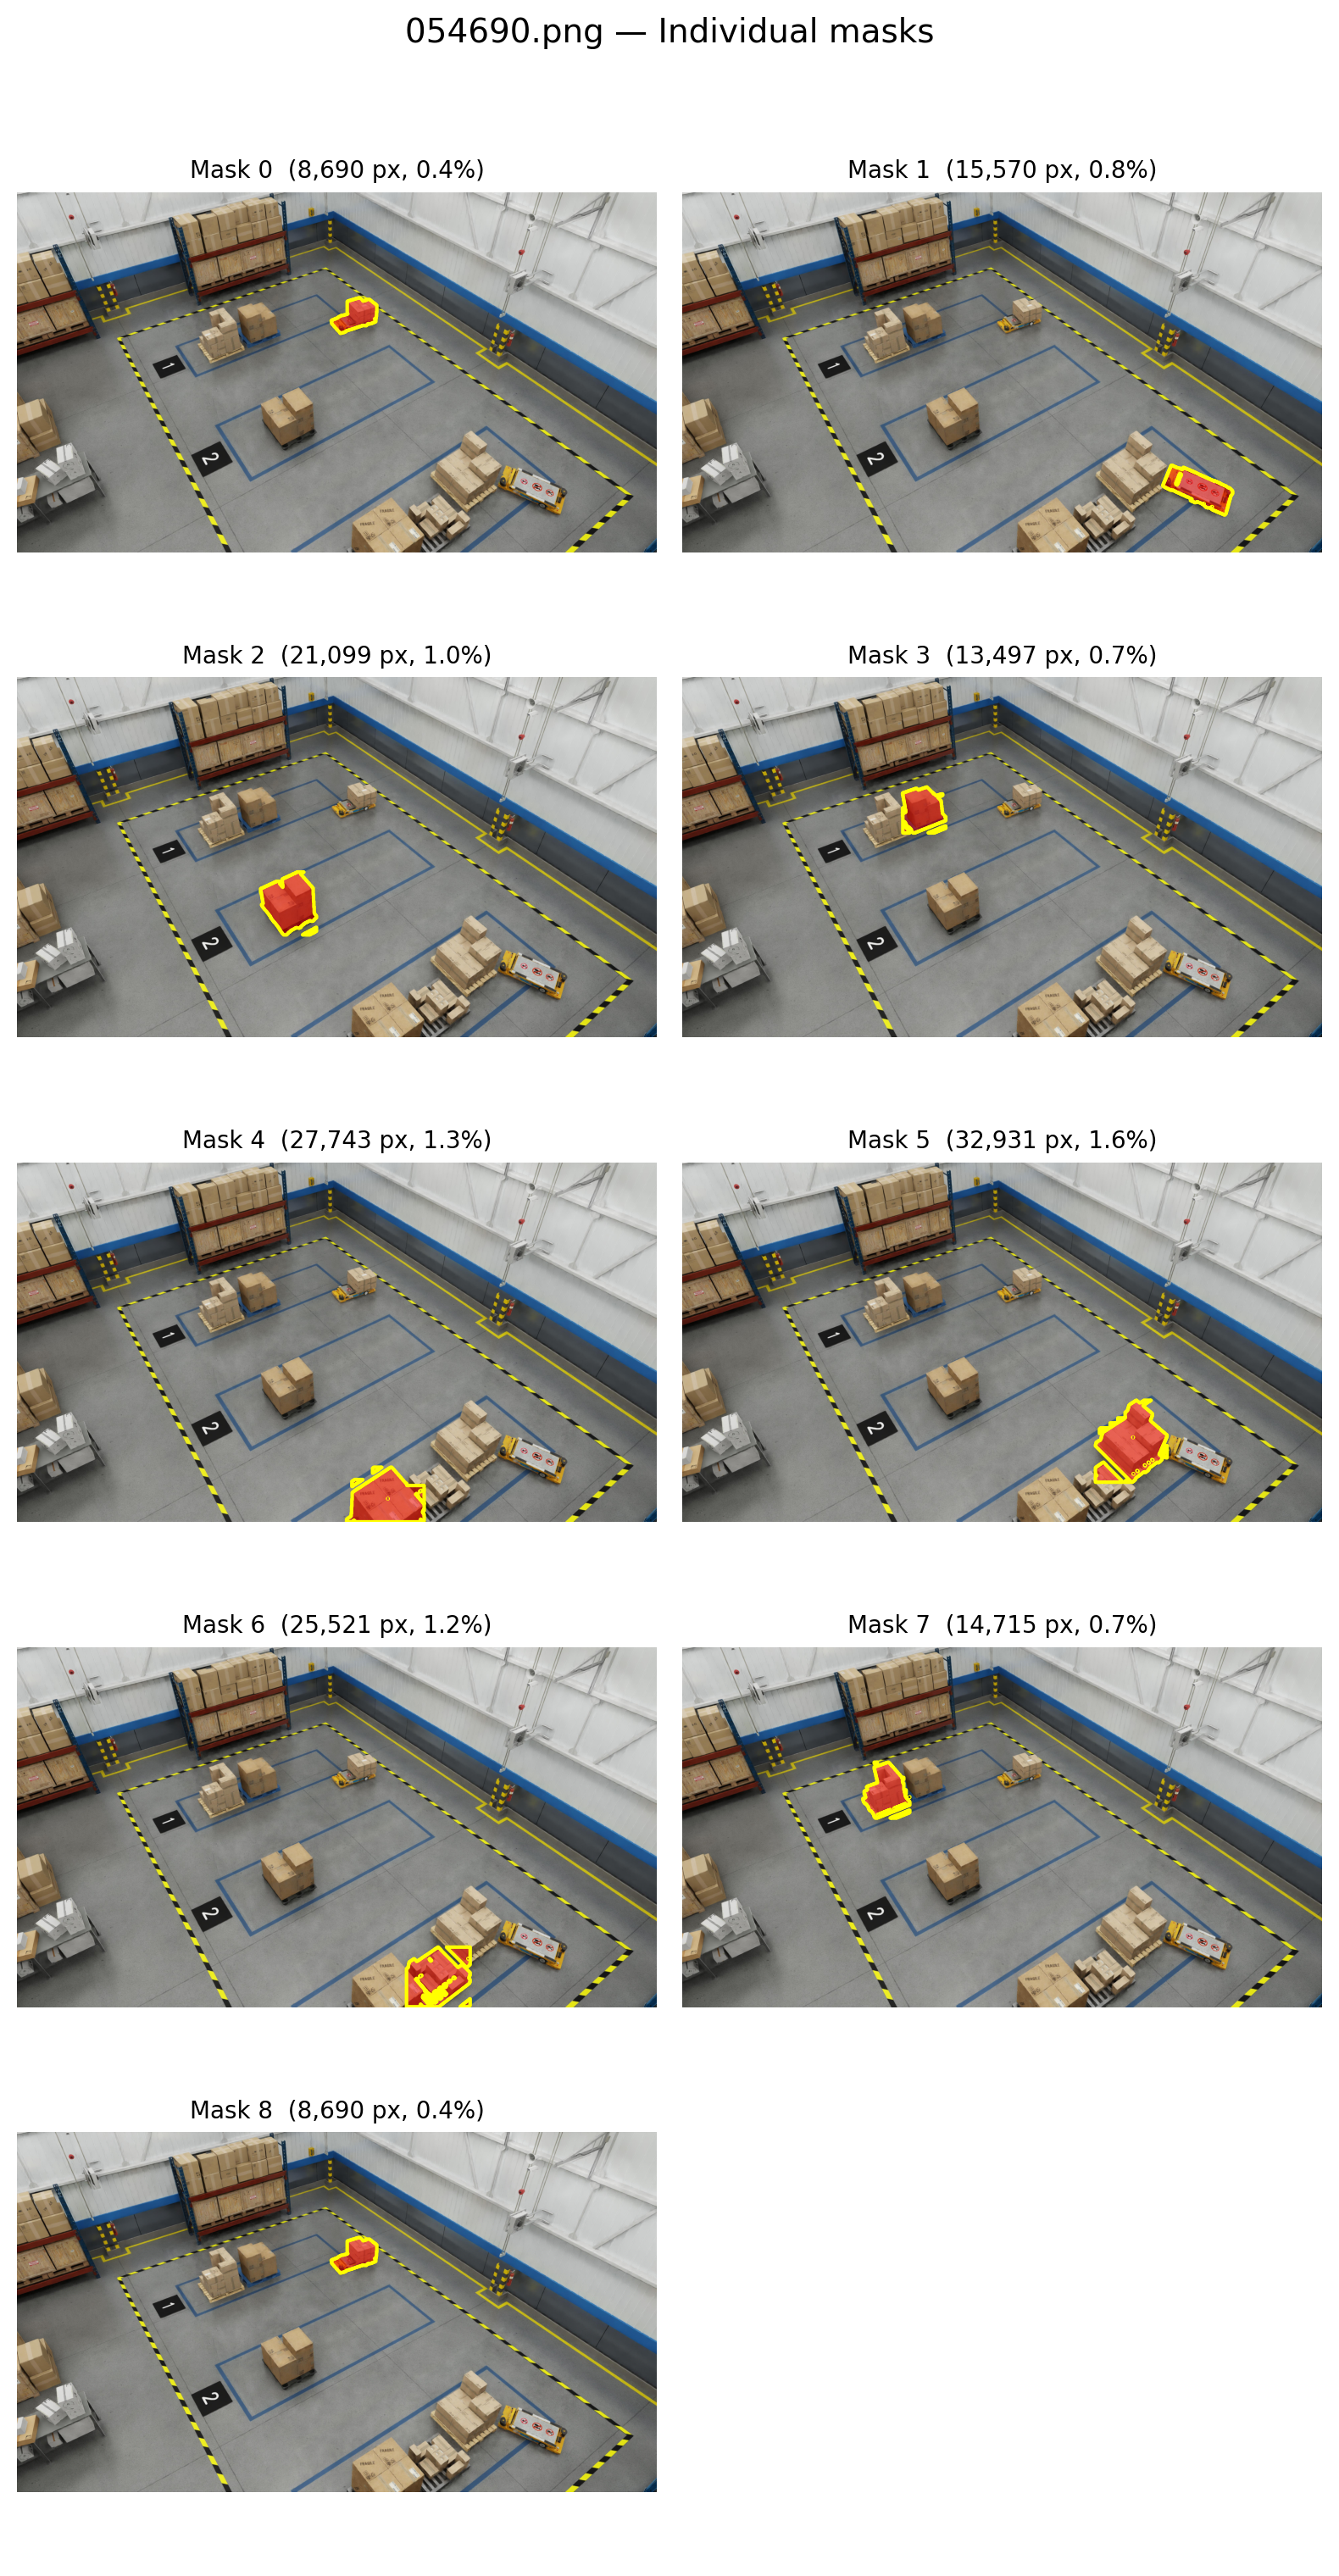

In [5]:
# ============================================================
# Plot 2: Individual masks (one per <mask> token)
# ============================================================
cols = min(2, n_masks)
rows = (n_masks + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows), dpi=200)
if n_masks == 1:
    axes = np.array([axes])
axes = axes.flatten()

for i, mask in enumerate(masks):
    ax = axes[i]
    ax.imshow(img_np)

    # Red overlay for this mask
    overlay = np.zeros((*mask.shape, 4), dtype=np.float32)
    overlay[mask, 0] = 1.0  # red
    overlay[mask, 3] = 0.5
    ax.imshow(overlay)

    # Contour
    ax.contour(mask.astype(float), levels=[0.5], colors=["yellow"], linewidths=1.5)

    # Stats
    ys, xs = np.where(mask)
    n_pix = mask.sum()
    pct = 100.0 * n_pix / (H * W)
    ax.set_title(f"Mask {i}  ({n_pix:,} px, {pct:.1f}%)", fontsize=10)
    ax.axis("off")

# Hide unused axes
for j in range(n_masks, len(axes)):
    axes[j].axis("off")
plt.suptitle(f"{image_name} — Individual masks", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

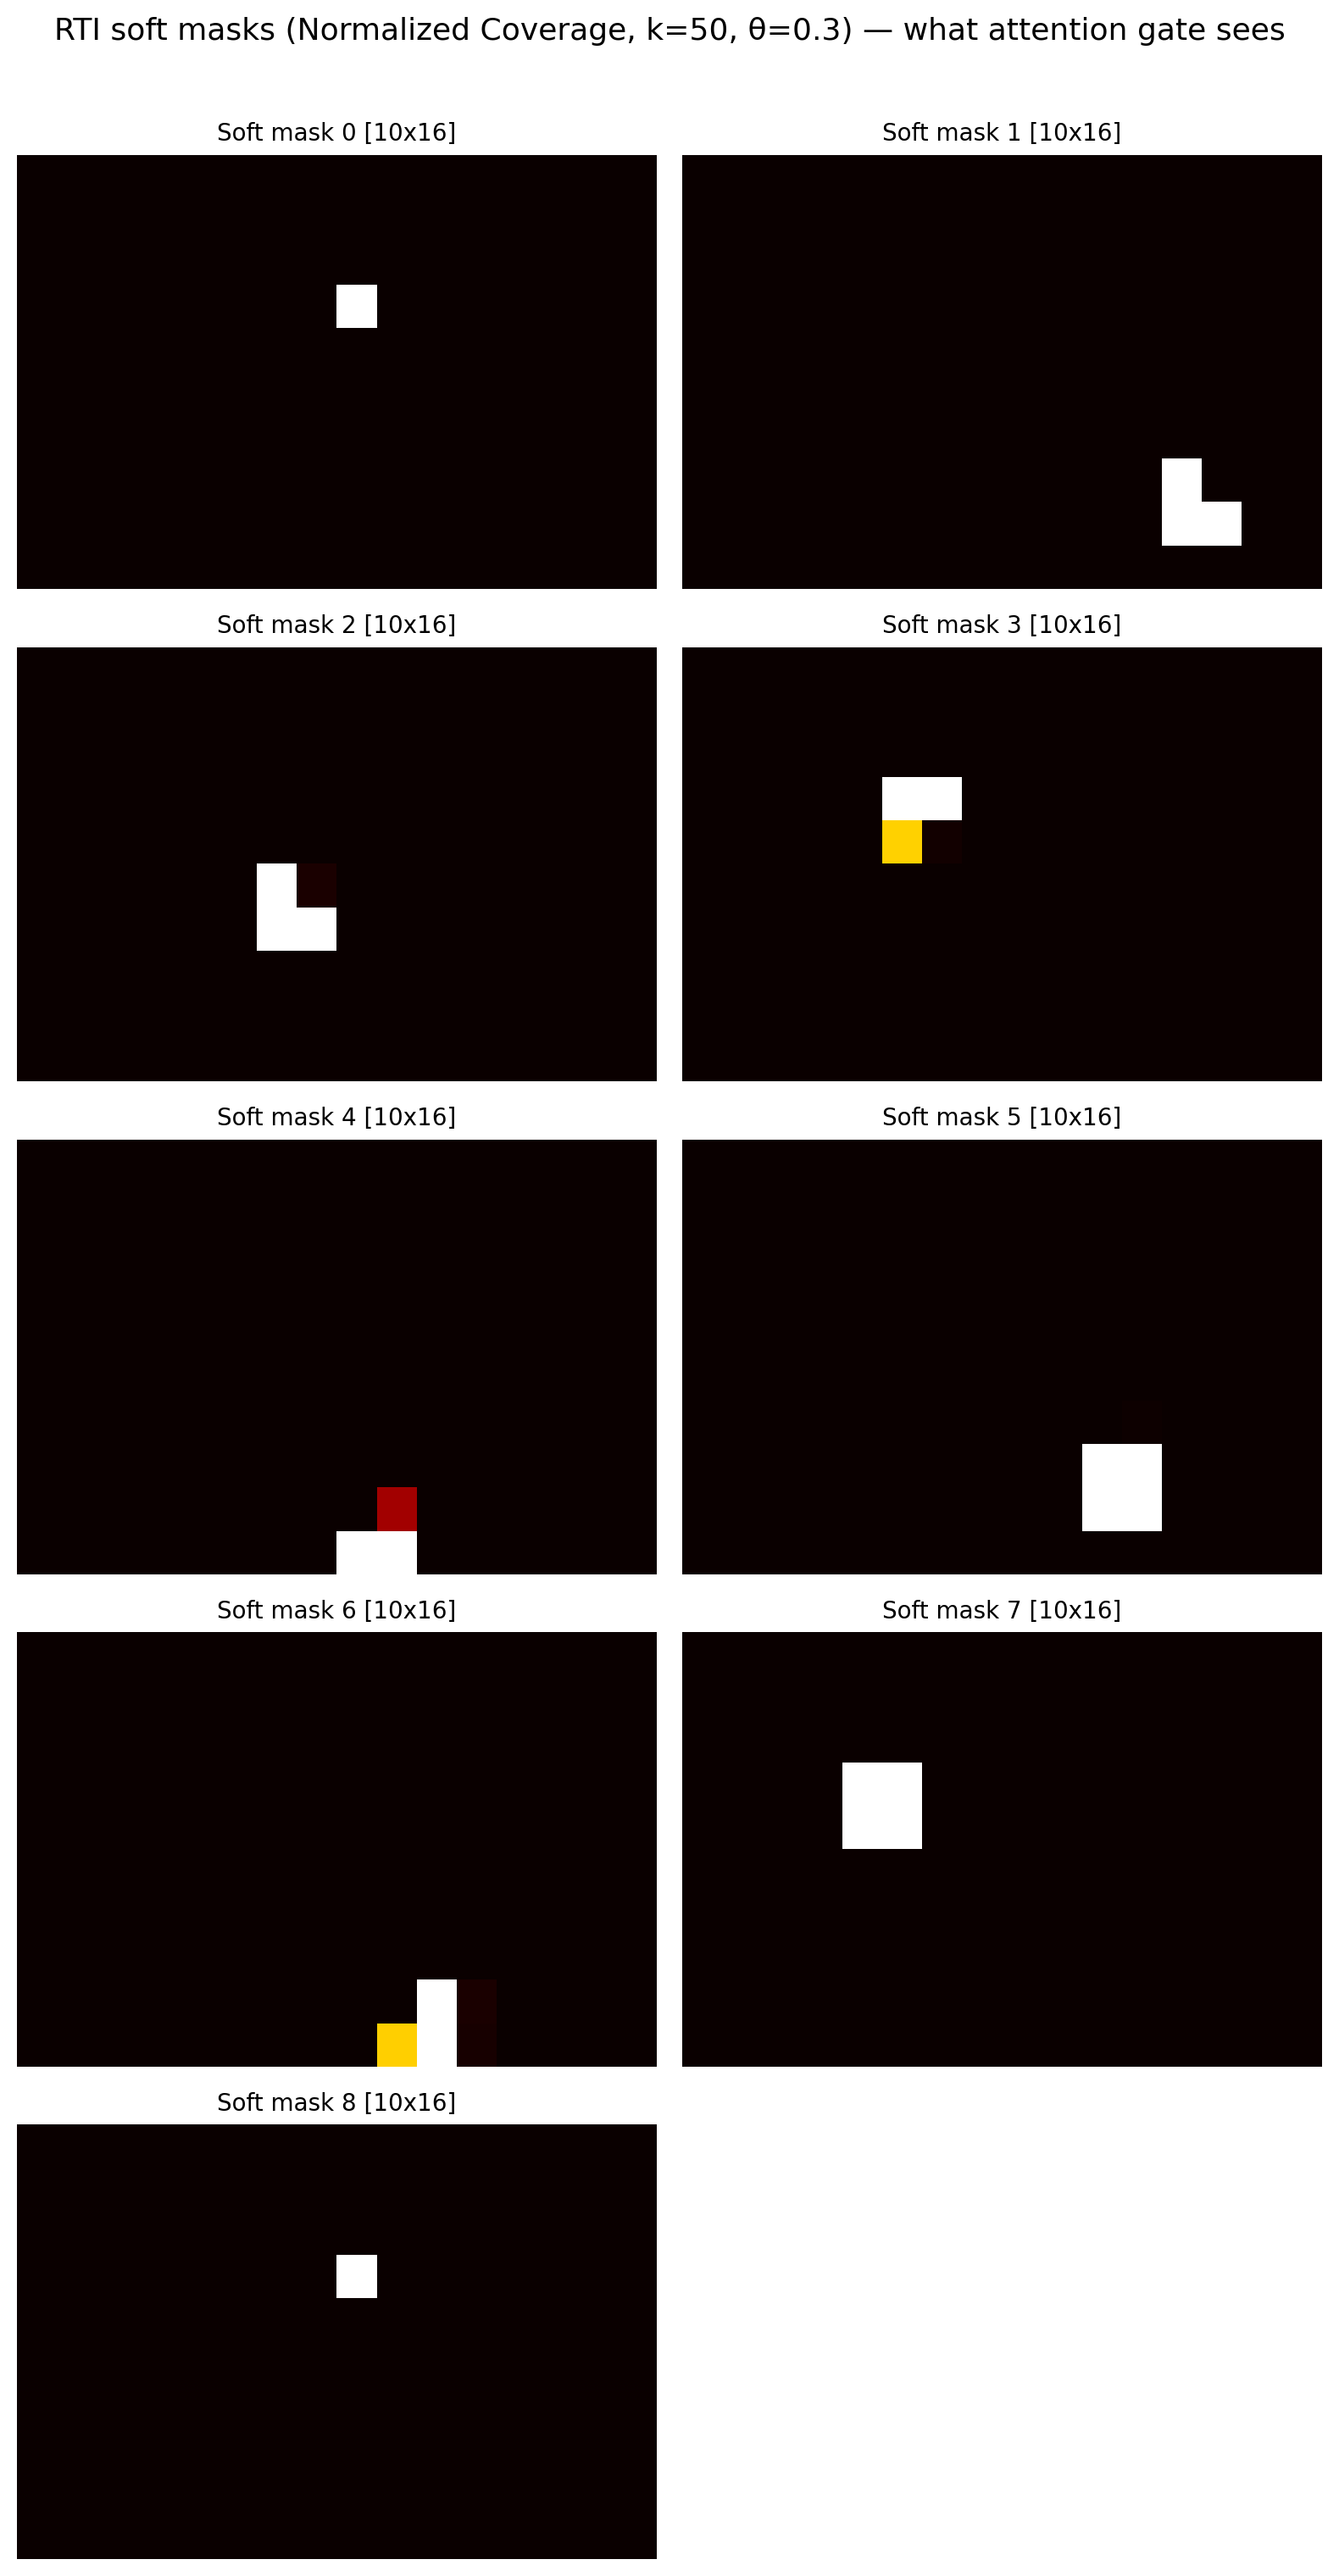

In [6]:
# ============================================================
# Plot 3: Soft coverage masks (what RTI actually sees)
# ============================================================
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Simulate RTI's _rle_to_soft_mask
# 512×320 → patches: 32×20 → after 2×2 merger: 16×10
h_vis, w_vis = 10, 16  # after 2x2 merger: 20//2, 32//2 (320p)

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows), dpi=200)
if n_masks == 1:
    axes = np.array([axes])
axes = axes.flatten()

for i, (mask, rle) in enumerate(zip(masks, rle_list)):
    ax = axes[i]

    # 1. Coverage: adaptive_avg_pool2d(binary_mask) -> [h_vis, w_vis]
    t = torch.from_numpy(mask.astype(np.float32))
    coverage = F.adaptive_avg_pool2d(
        t.unsqueeze(0).unsqueeze(0), (h_vis, w_vis)
    ).squeeze().numpy()
    
    # 2. Relative Coverage Normalization 
    # Guarantees the object's densest grid block is always 1.0
    coverage = coverage / (coverage.max() + 1e-8)
    
    # 3. DB-style soft mask: sigmoid(50 * (coverage - 0.3))
    soft = 1.0 / (1.0 + np.exp(-50.0 * (coverage - 0.3)))
    
    ax.imshow(soft, cmap="hot", vmin=0, vmax=1, aspect="auto")
    ax.set_title(f"Soft mask {i} [{h_vis}x{w_vis}]", fontsize=10)
    ax.axis("off")

for j in range(n_masks, len(axes)):
    axes[j].axis("off")

plt.suptitle(f"RTI soft masks (Normalized Coverage, k=50, θ=0.3) — what attention gate sees",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### Image [10x16] that Attention Gate sees
| Color            | Value      | Meaning                               |
|------------------|------------|---------------------------------------|
| Black            | 0.0        | No mask coverage at all               |
| Dark red         | ~0.0–0.2   | Very low coverage (boundary patches)  |
| Bright red/orange| ~0.3–0.7   | Partial coverage (sigmoid transition zone) |
| Yellow/white     | ~0.8–1.0   | Full coverage (mask interior)         |